In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the handwritten digits dataset

digits = load_digits()

# Store images and labels
images = digits.images
labels = digits.target

# Display dataset information
print("Total Images:", len(images))
print("Image Shape:", images[0].shape)
print("Labels:", np.unique(labels))

Total Images: 1797
Image Shape: (8, 8)
Labels: [0 1 2 3 4 5 6 7 8 9]


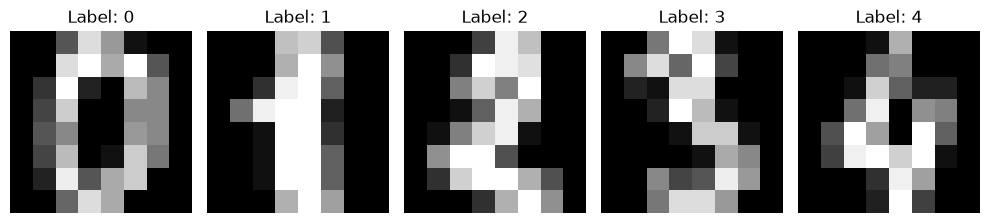

In [3]:
# Display the first 5 handwritten digit images

plt.figure(figsize=(10, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# OpenCV preprocessing: resize and normalize images

processed_images = []

for img in images:
    # Convert pixel values from 0-16 to 0-255
    img = (img * 16).astype(np.uint8)

    # Resize image to 32x32 using OpenCV
    img = cv2.resize(img, (32, 32))

    # Normalize pixel values to the range 0-1
    img = img / 255.0

    processed_images.append(img)

processed_images = np.array(processed_images)

print("Original Image Shape:", images[0].shape)
print("Processed Image Shape:", processed_images[0].shape)
print("Pixel Value Range:", processed_images.min(), "to", processed_images.max())

Original Image Shape: (8, 8)
Processed Image Shape: (32, 32)
Pixel Value Range: 0.0 to 0.9411764705882353


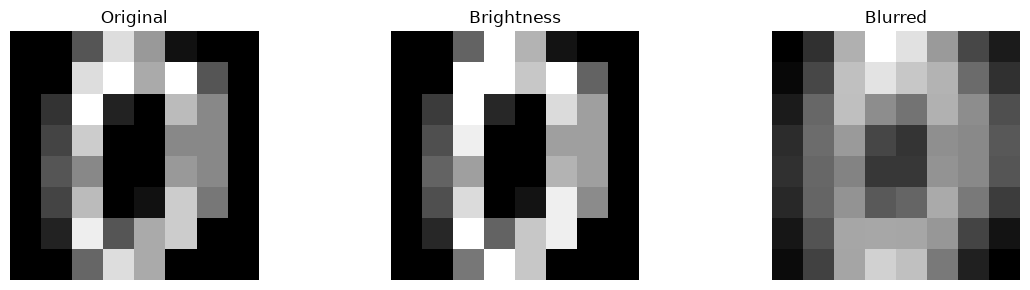

In [5]:
# Image enhancement using OpenCV

# Select one sample image
sample = (images[0] * 16).astype(np.uint8)

# Increase brightness
brightness = cv2.convertScaleAbs(sample, alpha=1.0, beta=50)

# Apply Gaussian blur
blurred = cv2.GaussianBlur(sample, (3, 3), 0)

# Display original and enhanced images
plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
plt.imshow(sample, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(brightness, cmap="gray")
plt.title("Brightness")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blurred, cmap="gray")
plt.title("Blurred")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Prepare processed images for machine learning

# Flatten each 32x32 image into a one-dimensional vector
X = processed_images.reshape(len(processed_images), -1)

# Target labels
y = labels

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (1797, 1024)
Label Shape: (1797,)


In [7]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Images:", len(X_train))
print("Testing Images:", len(X_test))

Training Images: 1437
Testing Images: 360


In [8]:
# Create and train the SVM classifier

model = SVC(kernel="linear")

print("Training SVM model...")

model.fit(X_train, y_train)

print("SVM model trained successfully!")

Training SVM model...
SVM model trained successfully!


In [9]:
# Make predictions on the test data

predictions = model.predict(X_test)

# Calculate model accuracy
accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", round(accuracy * 100, 2), "%")

Model Accuracy: 0.8722222222222222
Model Accuracy (%): 87.22 %


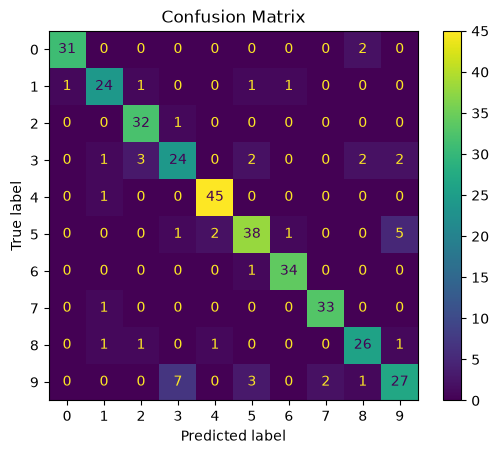

In [10]:
# Create and display the confusion matrix

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.unique(y)
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

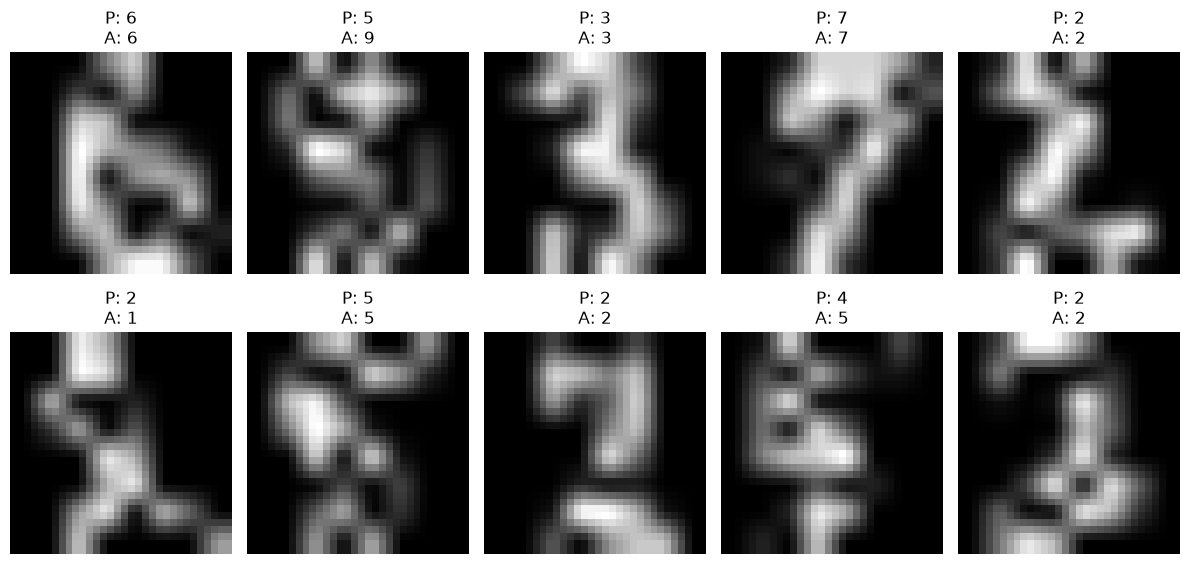

In [11]:
# Display test images with predicted and actual labels

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Reshape the flattened test image back to 32x32
    image = X_test[i].reshape(32, 32)

    plt.imshow(image, cmap="gray")
    plt.title(f"P: {predictions[i]}\nA: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()